# 18. Calculating Logarithmic returns

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import alpaca_trade_api as alpaca

api = alpaca.REST('PKSVKIO35NZMZK00L2Z3', 'ifYF17huHaOsPFqbfkrPGbI9VMxPMHq36RZXJ9np', 'https://paper-api.alpaca.markets')

In [6]:
symbol = 'Q.MX'
start_date = '2024-12-01'
end_date = '2025-05-01'

Q = api.get_bars(symbol, "1day", start=start_date, end=end_date).df
print (Q)

Empty DataFrame
Columns: []
Index: []


In [9]:
Q = pd.read_csv('..\Dataset\Q.csv', index_col = 'Mes')
Q

,Titulos Mes Anterior,Titulos Mes Actual,Num Emisora,Emisora,Serie,Costo Unitario,Precio Inicial,Precio Final,Diferencial,Valor de Mercado,Plusvalia o Minusvalia,Tendencia Accionaria
Mes,,,,,,,,,,,,
2025-05-01,290.0,290,1,Q,*,176.96,216.10,209.82,-6.28,60847.8,9529.4,NaN
2025-04-01,290.0,290,1,Q,*,176.96,177.83,216.10,38.27,62669.0,11350.6,NaN
2025-03-01,NaN,290,1,Q,*,176.96,177.83,177.83,51570.70,252.3,NaN,NaN


In [11]:
Q['log_return'] = np.log(Q['Precio Final'] / Q['Precio Final'].shift(1))
print (Q['log_return'])

Mes
2025-05-01         NaN
2025-04-01    0.029491
2025-03-01   -0.194913
Name: log_return, dtype: float64


# Yahoo Finance API

https://www.youtube.com/watch?v=52jZRDjvrIQ

In [ ]:
# Instalar yfinance
!pip install yfinance

In [ ]:
!pip install pandas_datareader

In [ ]:
# Importar yfinance
import yfinance as yf

In [ ]:
from datetime import datetime

tickers = ['NFLX', '^IXIC', 'TSLA']
inicio = datetime(2018,9,26)
fin = datetime(2023,9,26)

datos = pdr.get_data_yahoo(tickers, inicio, fin)

In [30]:
# Descargar datos mensuales de AAPL desde 2020
ticker = yf.Ticker("Q.MX")
data = ticker.history(start='2024-08-01', end='2025-06-01', interval="1mo")
print(data)

                                 Open        High         Low       Close  \
Date                                                                        
2024-08-01 00:00:00-06:00  169.938292  174.616389  149.767661  154.377258   
2024-09-01 00:00:00-06:00  154.220662  162.373082  145.060201  150.716980   
2024-10-01 00:00:00-06:00  150.178704  154.543631  132.278622  136.085693   
2024-11-01 00:00:00-06:00  137.680930  152.087125  127.238398  150.100403   
2024-12-01 00:00:00-06:00  150.276575  185.969097  150.256997  170.779953   
2025-01-01 00:00:00-06:00  170.691869  175.184015  154.670841  168.871521   
2025-02-01 00:00:00-06:00  167.794971  204.965297  166.346526  193.191757   
2025-03-01 00:00:00-06:00  191.987986  195.521028  165.661455  174.107468   
2025-04-01 00:00:00-06:00  174.479364  214.262767  158.428991  212.324982   
2025-05-01 00:00:00-06:00  211.395249  232.123720  199.690209  203.575577   

                             Volume  Dividends  Stock Splits  
Date        

__NOTE:__ Los valores de 'Close' coinsiden con 'Adj Close' en yahoofinance pero los de apertura y cierro no

https://finance.yahoo.com/quote/Q.MX/history/?frequency=1mo

In [32]:
tickers = ['AAPL', 'MSFT', 'GOOGL']

# Descargar precios mensuales desde 2020
data = yf.download(tickers, start='2020-01-01', interval='1mo')

# Mostrar solo precios de cierre ajustado
close = data['Close']
print(close.head())

C:\Users\roly_\AppData\Local\Temp\ipykernel_18936\3647505023.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2020-01-01', interval='1mo')
[*********************100%***********************]  3 of 3 completed

Ticker           AAPL      GOOGL        MSFT
Date                                        
2020-01-01  74.835602  71.211914  162.198898
2020-02-01  66.094994  66.563293  154.366730
2020-03-01  61.630035  57.751144  150.680023
2020-04-01  71.205719  66.933586  171.221649
2020-05-01  77.056313  71.248703  175.081573


In [34]:
ticker = yf.Ticker("Q.MX")
data = ticker.history(start='2024-08-01', end='2025-06-01', interval="1mo")['Close']
print(data)

Date
2024-08-01 00:00:00-06:00    154.377258
2024-09-01 00:00:00-06:00    150.716980
2024-10-01 00:00:00-06:00    136.085693
2024-11-01 00:00:00-06:00    150.100403
2024-12-01 00:00:00-06:00    170.779953
2025-01-01 00:00:00-06:00    168.871521
2025-02-01 00:00:00-06:00    193.191757
2025-03-01 00:00:00-06:00    174.107468
2025-04-01 00:00:00-06:00    212.324982
2025-05-01 00:00:00-06:00    203.575577
Name: Close, dtype: float64


# Generar CSV con precio final

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data
# 1. Sacar los precios finales de cada fondo
tickers = ['SCOTDVC', 'SCOT-FR', 'SCOTGL', 'SCOTIA1','SCOT-LB', 'SCOT-RV', 'SCOTUSA']

new_data = pd.DataFrame()

for t in tickers:    
  path = "../Dataset/" + t + ".csv"
  df = pd.read_csv(path, usecols=['Mes', 'Precio Final'], parse_dates=['Mes'])
  df.set_index('Mes', inplace=True)
  df.rename(columns={'Precio Final': t}, inplace=True)

  # Unimos los datos al dataframe principal por fecha
  if new_data.empty:
    new_data = df
  else:
    new_data = new_data.join(df, how='outer')

# Opcional: ordena por fecha
new_data.sort_index(inplace=True)

# 2. Generar un archivo csv con los precios finales
new_data.to_csv('../Dataset/8_stocks_2024.csv')


In [62]:
# Add Q stocks
import pandas as pd
import yfinance as yf

df = pd.read_csv('../Dataset/8_stocks_2024.csv', parse_dates = ['Mes'])
df.set_index('Mes', inplace=True)

In [63]:
# Crear objeto del ticker
accion = yf.Ticker("Q.MX")

# Descargar precios mensuales desde la fecha de tu CSV
inicio = df.index.min().strftime('%Y-%m-%d')
nuevo = accion.history(start=inicio, end='2025-06-01', interval='1mo')

# Extraer solo 'Adj Close' y renombrar columna
nuevo = nuevo[['Close']].rename(columns={'Close': 'Q.MX'})
nuevo.index = nuevo.index.to_period('M').to_timestamp()

C:\Users\roly_\AppData\Local\Temp\ipykernel_18936\448049087.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  nuevo.index = nuevo.index.to_period('M').to_timestamp()


In [64]:
#print (nuevo.index.names)
nuevo


,Q.MX
Date,
2024-06-01,182.015213
2024-07-01,168.313675
2024-08-01,154.377258
2024-09-01,150.716980
2024-10-01,136.085693
2024-11-01,150.100403
2024-12-01,170.779953
2025-01-01,168.871521
2025-02-01,193.191757


In [65]:
# Unir por índice (fecha)
df_completo = df.join(nuevo, how='left')

In [66]:
df_completo

,SCOTDVC,SCOT-FR,SCOTGL,SCOTIA1,SCOT-LB,SCOT-RV,SCOTUSA,Q.MX
Mes,,,,,,,,
2024-06-01,1.867963,1.518639,8.733787,2.292458,0.626070,2.912830,22.375090,182.015213
2024-07-01,1.885802,1.558266,8.969214,2.310290,0.657369,2.907911,21.762569,168.313675
2024-08-01,1.899869,1.608674,9.688517,2.326902,0.705676,2.928799,24.075382,154.377258
2024-09-01,1.928339,1.658239,9.932473,2.344469,0.721017,2.976345,24.464433,150.716980
2024-10-01,1.924493,1.671792,9.938278,2.359236,0.734899,2.887687,25.405753,136.085693
2024-11-01,1.938746,1.610585,10.276987,2.375557,0.778594,2.825952,26.343587,150.100403
2024-12-01,1.945413,1.539694,10.074264,2.391975,0.746704,2.814855,26.512014,170.779953
2025-01-01,1.967606,1.637020,10.446506,2.408701,0.771177,2.985044,26.836575,168.871521
2025-02-01,1.993621,1.670522,9.983943,2.423415,0.758720,3.015334,25.703151,193.191757


In [67]:
df_completo.to_csv('../Dataset/8_stocks_2024.csv')

# 19. Calculating the return of a portfolio

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

portfolio = pd.read_csv('../Dataset/8_stocks_2024.csv', index_col = 'Mes')
portfolio

,SCOTDVC,SCOT-FR,SCOTGL,SCOTIA1,SCOT-LB,SCOT-RV,SCOTUSA,Q.MX
Mes,,,,,,,,
2024-06-01,1.867963,1.518639,8.733787,2.292458,0.626070,2.912830,22.375090,182.015213
2024-07-01,1.885802,1.558266,8.969214,2.310290,0.657369,2.907911,21.762569,168.313675
2024-08-01,1.899869,1.608674,9.688517,2.326902,0.705676,2.928799,24.075382,154.377258
2024-09-01,1.928339,1.658239,9.932473,2.344469,0.721017,2.976345,24.464433,150.716980
2024-10-01,1.924493,1.671792,9.938278,2.359236,0.734899,2.887687,25.405753,136.085693
2024-11-01,1.938746,1.610585,10.276987,2.375557,0.778594,2.825952,26.343587,150.100403
2024-12-01,1.945413,1.539694,10.074264,2.391975,0.746704,2.814855,26.512014,170.779953
2025-01-01,1.967606,1.637020,10.446506,2.408701,0.771177,2.985044,26.836575,168.871521
2025-02-01,1.993621,1.670522,9.983943,2.423415,0.758720,3.015334,25.703151,193.191757


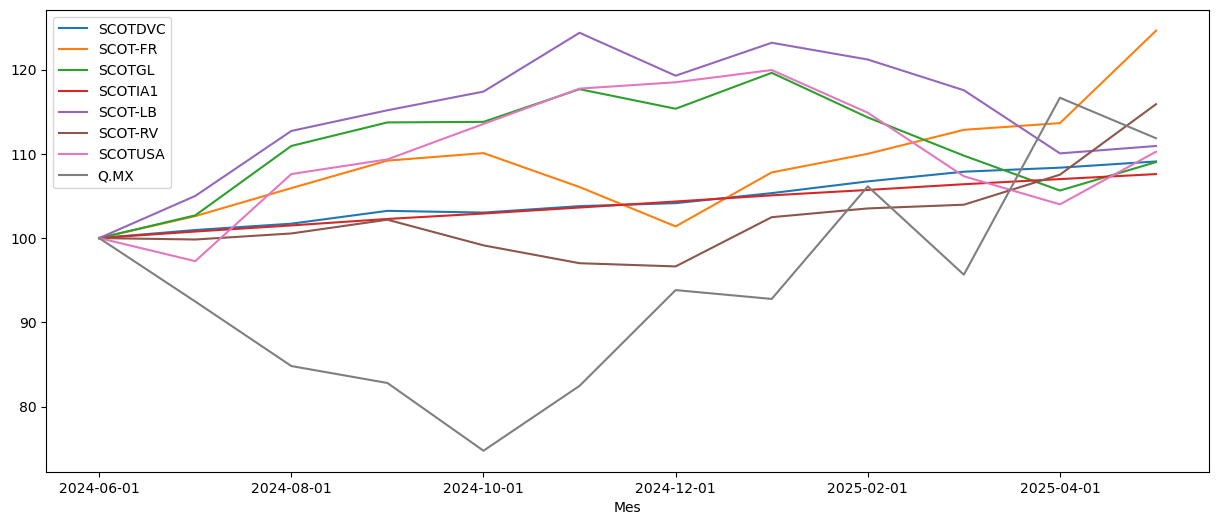

In [69]:
# Normalize to a hundred
(portfolio / portfolio.iloc[0] * 100).plot(figsize=(15,6))
plt.show()

In [70]:
#simp_return = (portfolio / portfolio.shift(1)) -1
simp_return = np.log(portfolio / portfolio.shift(1))
simp_return.tail()

,SCOTDVC,SCOT-FR,SCOTGL,SCOTIA1,SCOT-LB,SCOT-RV,SCOTUSA,Q.MX
Mes,,,,,,,,
2025-01-01,0.011343,0.061294,0.036284,0.006968,0.032249,0.058704,0.012168,-0.011238
2025-02-01,0.013135,0.020259,-0.045289,0.006090,-0.016285,0.010096,-0.043152,0.134545
2025-03-01,0.010719,0.025519,-0.040437,0.006394,-0.030536,0.004250,-0.067884,-0.104011
2025-04-01,0.004408,0.007041,-0.038461,0.005697,-0.065866,0.033696,-0.031572,0.198445
2025-05-01,0.006794,0.092107,0.031442,0.005530,0.007932,0.074925,0.058329,-0.042081


In [71]:
weights = np.array([0.355806, 0.041236, 0.045192, 0.401368, 0.048522, 0.042229, 0.050032, 0.015614])
print (weights.sum())


0.999999


In [94]:
(simp_return.mean() * 250)

SCOTDVC    1.977834
SCOT-FR    4.999751
SCOTGL     1.961876
SCOTIA1    1.663053
SCOT-LB    2.356845
SCOT-RV    3.351279
SCOTUSA    2.216769
Q.MX       2.544251
dtype: float64

In [72]:
annual_return = simp_return.mean() * 250
dot_prod = np.dot(annual_return, weights)

print (str(round(dot_prod,4) * 100) + '%')

207.26%


# 23. Calculating portfolio Risk

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sec_data = pd.read_csv('../Dataset/8_stocks_2024.csv', index_col = 'Mes')
sec_returns = np.log(sec_data / sec_data.shift(1))
#print (sec_data.head())

             SCOTDVC   SCOT-FR    SCOTGL   SCOTIA1   SCOT-LB   SCOT-RV  \
Mes                                                                      
2024-06-01  1.867963  1.518639  8.733787  2.292458  0.626070  2.912830   
2024-07-01  1.885802  1.558266  8.969214  2.310290  0.657369  2.907911   
2024-08-01  1.899869  1.608674  9.688517  2.326902  0.705676  2.928799   
2024-09-01  1.928339  1.658239  9.932473  2.344469  0.721017  2.976345   
2024-10-01  1.924493  1.671792  9.938278  2.359236  0.734899  2.887687   

              SCOTUSA        Q.MX  
Mes                                
2024-06-01  22.375090  182.015213  
2024-07-01  21.762569  168.313675  
2024-08-01  24.075382  154.377258  
2024-09-01  24.464433  150.716980  
2024-10-01  25.405753  136.085693  


In [75]:
weights = np.array([0.355806, 0.041236, 0.045192, 0.401368, 0.048522, 0.042229, 0.050032, 0.015614])
cov_matrix = sec_returns.cov() * 250
pfolio_vol = np.dot(weights, np.dot(cov_matrix, weights)) ** 0.5

print ('Riesgo del portafolio:', str(round(pfolio_vol, 5) * 100) + '%')

Riesgo del portafolio: 10.424%


# 27,28,29 Obtaining the Efficient Frontier

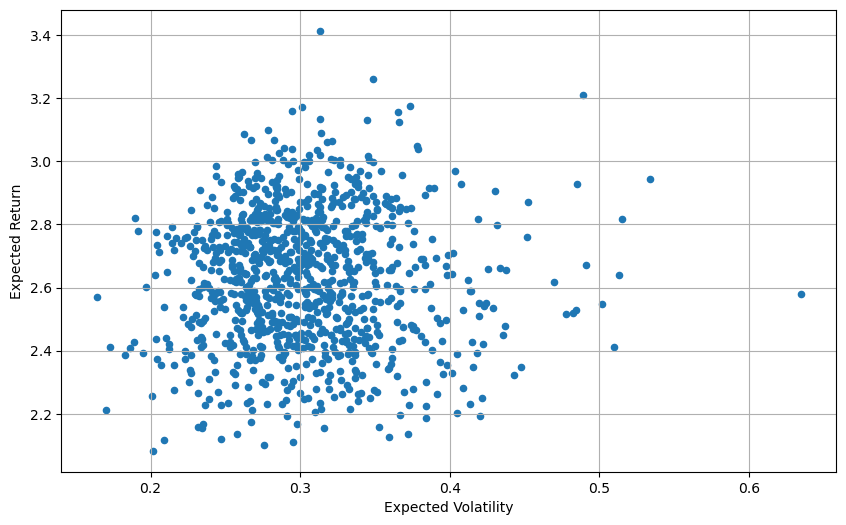

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pf_data = pd.read_csv('../Dataset/8_stocks_2024.csv', index_col = 'Mes')

# Calculate the logarithmic returns
log_returns = np.log(pf_data / pf_data.shift(1))

# Create a variable that carries the number of assets in your portfolio
num_assets = len(pf_data.columns)

# Obtain random values for weights (the sum must be 1)
#weights = np.random.random(num_assets)
#weights /= np.sum(weights)

# Create two empty lists
pf_returns = []
pf_volatilities = []

# Create a loop with 1,000 iterations that will generate random weights

for x in range (1000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    pf_returns.append(np.sum(weights * log_returns.mean()) * 250)
    pf_volatilities.append(np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights))))

# Transform the obtained lists in NumPy arrays    
pf_returns = np.array(pf_returns)
pf_volatilities = np.array(pf_volatilities)

# Create a dictionary
portfolios = pd.DataFrame({'Return': pf_returns, 'Volatility': pf_volatilities})

# Plot the data
portfolios.plot(x='Volatility', y='Return', kind='scatter', figsize=(10,6), grid=True)
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')
plt.show()
